In [4]:
import emcee
import matplotlib.pyplot as plt
import pyccl as ccl
import numpy as np
import corner
from IPython.display import display, Math
import seaborn as sns
import matplotlib.colors as mcolors
import harmonic as hm

print(emcee.__version__)

3.1.6


In [5]:
# Define cosmology

cosmo_universe = ccl.Cosmology(Omega_c = 0.269619, 
                          Omega_b = 0.050041,
                          h = 0.6688,
                          n_s = 0.9626,
                          A_s = 2.092e-9)

Bias_distribution_fiducial = np.array([1.562362,
                             1.732963,
                             1.913252,
                             2.100644,
                             2.293210])

In [6]:
labels = [r"$\Omega_c$", r"$\mu_0$",r"$\Sigma_0$", r"$10^{9}A_s$", r"$h$", r"$n_s$", r"$\omega_b$",\
         r'$b_1$', r'$b_2$', r'$b_3$', r'$b_4$', r'$b_5$']

value1 = [cosmo_universe["Omega_c"], 0.0,0.0, cosmo_universe["A_s"]*1e9, cosmo_universe["h"],\
          cosmo_universe["n_s"],cosmo_universe["Omega_b"]*cosmo_universe["h"]**2,\
         Bias_distribution_fiducial[0], Bias_distribution_fiducial[1],\
         Bias_distribution_fiducial[2],Bias_distribution_fiducial[3],\
         Bias_distribution_fiducial[4]]

lower_value1 = [0.28 - 0.06, -1.5,-1.5,  1.7, 0.61 , 0.92, 0.04, 0.8,0.8,0.8,0.8,0.8]
upper_value1 = [0.36 - 0.04, 1.5,1.5,  2.5, 0.73,1 , 0.06, 3.0,3.0,3.0,3.0,3.0]



## ESS, full PCA

In [7]:
# Read the HDF5 file (note: no need to reset the backend here)
#filename = "/scratch/c2042999/chains/mcmc_ESS_muSigma_PCACuts_nofsigma8_DEparam.h5"
filename = "/scratch/c2042999/chains_final/mcmc_ESS_muSigma_PCACuts_Sigma1_noparam_mild.h5"

while True:
    try:
        reader = emcee.backends.HDFBackend(filename, read_only=True)
        break  # Exit the loop once file is read successfully
    except BlockingIOError:
        # Wait for some time before retrying
        print("File is locked, retrying...")
        time.sleep(0.1)  # Sleep for 1 second before trying again

# Check how many steps have been completed so far
n_steps_completed = reader.iteration
print(f"Number of steps completed: {n_steps_completed}")

nburn = 500
thin = 20
lnprob = reader.get_log_prob(discard=nburn, thin=thin)
raw_chain = reader.get_chain(discard=nburn, thin=thin)
print(f"Current raw chain shape: {raw_chain.shape}")

tau = reader.get_autocorr_time(tol=0)
max_tau_ratio = np.max(tau * 100 / reader.iteration)
converged = max_tau_ratio < 1
print("Current iteration: {}".format(reader.iteration))
print("Max 100 x Tau/N: {}".format(max_tau_ratio))


# Step 3: Transpose chain to shape (nchains, nsteps, ndim)
samples = np.transpose(raw_chain, (1, 0, 2))  # emcee v3 stores shape as (nsteps, nchains, ndim)
lnprob = np.transpose(lnprob, (1, 0))         # same logic for log prob

# Step 4: Ensure contiguity in memory (not strictly necessary, but can help with some tools)
samples = np.ascontiguousarray(samples)
lnprob = np.ascontiguousarray(lnprob)

# Step 5: Add to Harmonic Chains
ndim = samples.shape[2]
chains = hm.Chains(ndim)
chains.add_chains_3d(samples, lnprob)

Number of steps completed: 14400
Current raw chain shape: (695, 80, 12)
Current iteration: 14400
Max 100 x Tau/N: 0.9997580733328905


In [8]:
# Get the raw chain and log-probabilities
raw_chain = reader.get_chain(flat=False)  # Unflattened chain: (steps, walkers, parameters)
log_prob = reader.get_log_prob(flat=False)  # Unflattened log-probabilities: (steps, walkers)

# Calculate burn-in index
n_burnin = 0  # Adjust if needed

# Remove the burn-in
raw_chain_burnin_removed = raw_chain[n_burnin:]  # Keep steps after burn-in
log_prob_burnin_removed = log_prob[n_burnin:]  # Keep log-probabilities after burn-in

# Flatten the chains after removing burn-in
raw_chain_flat = raw_chain_burnin_removed.reshape(-1, raw_chain.shape[-1])  # (samples, parameters)
log_prob_flat = log_prob_burnin_removed.reshape(-1)  # (samples,)

# Compute the mean of each parameter
mean_params = np.mean(raw_chain_flat, axis=0)

# Find the sample with the maximum log-probability
max_likelihood_index = np.argmax(log_prob_flat)
max_likelihood_params = raw_chain_flat[max_likelihood_index]

# Compute 1σ (68% confidence interval) from the posterior distribution
lower_1sigma, upper_1sigma = np.percentile(raw_chain_flat, [16, 84], axis=0)

print("max likelihood: ", np.max(log_prob_flat))
print("\nMaximum Likelihood Parameter Values (after burn-in):")
print(max_likelihood_params)

print("\n1σ Confidence Intervals (16th-84th percentile) for each parameter:")
for i, (ml_val, lower, upper) in enumerate(zip(max_likelihood_params, lower_1sigma, upper_1sigma)):
    print(f"{labels[i]}: {ml_val:.6f} (+{upper-ml_val:.6f} / -{ml_val-lower:.6f})")


max likelihood:  11.501096601482878

Maximum Likelihood Parameter Values (after burn-in):
[ 0.27673418  0.97896193 -0.01326981  2.0073297   0.66542757  0.96209936
  0.02242671  1.5772761   1.74210739  1.92166226  2.11005836  2.30269841]

1σ Confidence Intervals (16th-84th percentile) for each parameter:
$\Omega_c$: 0.276734 (+0.004709 / -0.007035)
$\mu_0$: 0.978962 (+0.079795 / -0.088353)
$\Sigma_0$: -0.013270 (+0.034566 / -0.022299)
$10^{9}A_s$: 2.007330 (+0.088335 / -0.076278)
$h$: 0.665428 (+0.012496 / -0.011714)
$n_s$: 0.962099 (+0.004773 / -0.003998)
$\omega_b$: 0.022427 (+0.000108 / -0.000205)
$b_1$: 1.577276 (+0.024785 / -0.023482)
$b_2$: 1.742107 (+0.026284 / -0.021071)
$b_3$: 1.921662 (+0.025824 / -0.021315)
$b_4$: 2.110058 (+0.025318 / -0.022393)
$b_5$: 2.302698 (+0.029051 / -0.022081)


In [11]:
"""Get the GR only version"""
#filename = "/scratch/c2042999/chains_final/mcmc_ESS_muSigma_PCACuts_Sigma1_mild.h5"
filename = "/scratch/c2042999/chains_final/mcmc_ESS_muSigma_PCACuts_Sigma1_noparam_mild_GRonly.h5"
while True:
    try:
        reader = emcee.backends.HDFBackend(filename, read_only=True)
        break  # Exit the loop once file is read successfully
    except BlockingIOError:
        # Wait for some time before retrying
        print("File is locked, retrying...")
        time.sleep(0.1)  # Sleep for 1 second before trying again

nburn = 400
thin = 20

raw_chain_PCAGRonlycuts = reader.get_chain(discard=nburn, thin=thin)
lnprob_GRonlycuts = reader.get_log_prob(discard=nburn, thin=thin)

# Check how many steps have been completed so far
n_steps_completed = reader.iteration
print(f"Number of steps completed: {n_steps_completed}")

# You can also manually access the raw chain and other properties
print(f"Current raw chain shape: {raw_chain_PCAGRonlycuts.shape}")


tau = reader.get_autocorr_time(tol=0)
max_tau_ratio = np.max(tau * 100 / reader.iteration)
converged = max_tau_ratio < 1
print("Current iteration: {}".format(reader.iteration))
print("Max 100 x Tau/N: {}".format(max_tau_ratio))

print(f"Current raw chain shape: {raw_chain.shape}")

# Step 3: Transpose chain to shape (nchains, nsteps, ndim)
samples_GR = np.transpose(raw_chain_PCAGRonlycuts, (1, 0, 2))  # emcee v3 stores shape as (nsteps, nchains, ndim)
lnprob_GRonlycuts = np.transpose(lnprob_GRonlycuts, (1, 0))         # same logic for log prob

# Step 4: Ensure contiguity in memory (not strictly necessary, but can help with some tools)
samples_GR = np.ascontiguousarray(samples_GR)
lnprob_GRonlycuts = np.ascontiguousarray(lnprob_GRonlycuts)

# Step 5: Add to Harmonic Chains
ndim = samples_GR.shape[2]
chains_GRonlycuts = hm.Chains(ndim)
chains_GRonlycuts.add_chains_3d(samples_GR, lnprob_GRonlycuts)


Number of steps completed: 11249
Current raw chain shape: (542, 80, 12)
Current iteration: 11249
Max 100 x Tau/N: 1.2651685866117874
Current raw chain shape: (14400, 80, 12)


In [12]:
chains_train, chains_infer = hm.utils.split_data(chains_GRonlycuts, training_proportion=0.5)

# Select RealNVP Model
n_scaled_layers = 2
n_unscaled_layers = 4
temperature = 0.8

model = hm.model.RealNVPModel(ndim, standardize=True, temperature=temperature)
epochs_num = 20
# Train model
model.fit(chains_train.samples, epochs=epochs_num, verbose= True)

# Instantiate harmonic's evidence class
ev = hm.Evidence(chains_infer.nchains, model)

# Pass the evidence class the inference chains and compute the evidence!
ev.add_chains(chains_infer)
ln_inv_evidence_GR = ev.ln_evidence_inv
err_ln_inv_evidence_GR = ev.compute_ln_inv_evidence_errors()

print('ln inverse evidence (harmonic) = {} +/- {}'.format(ln_inv_evidence_GR, err_ln_inv_evidence_GR))

Training NF: 100%|██████████████████████████████| 20/20 [00:18<00:00,  1.09it/s]


ln inverse evidence (harmonic) = 41.363800048828125 +/- (-0.020086185200840646, 0.019690661883648174)


In [13]:
"""Get the nDGP only version"""
#filename = "/scratch/c2042999/chains_final/mcmc_ESS_muSigma_PCACuts_Sigma1_mild.h5"
#filename = "/scratch/c2042999/chains_final/mcmc_ESS_muSigma_PCACuts_Sigma1_noparam_mild_GRonly.h5"
filename = "mcmc/mcmc_ESS_muSigma_PCACuts_Sigma1_noparam_mild_nDGPonly.h5"

while True:
    try:
        reader = emcee.backends.HDFBackend(filename, read_only=True)
        break  # Exit the loop once file is read successfully
    except BlockingIOError:
        # Wait for some time before retrying
        print("File is locked, retrying...")
        time.sleep(0.1)  # Sleep for 1 second before trying again

nburn = 400
thin = 20

raw_chain_PCAnDGPonlycuts = reader.get_chain(discard=nburn, thin=thin)
lnprob_nDGPonlycuts = reader.get_log_prob(discard=nburn, thin=thin)

# Check how many steps have been completed so far
n_steps_completed = reader.iteration
print(f"Number of steps completed: {n_steps_completed}")

# You can also manually access the raw chain and other properties
print(f"Current raw chain shape: {raw_chain_PCAnDGPonlycuts.shape}")


tau = reader.get_autocorr_time(tol=0)
max_tau_ratio = np.max(tau * 100 / reader.iteration)
converged = max_tau_ratio < 1
print("Current iteration: {}".format(reader.iteration))
print("Max 100 x Tau/N: {}".format(max_tau_ratio))

print(f"Current raw chain shape: {raw_chain.shape}")

# Step 3: Transpose chain to shape (nchains, nsteps, ndim)
samples_nDGP = np.transpose(raw_chain_PCAnDGPonlycuts, (1, 0, 2))  # emcee v3 stores shape as (nsteps, nchains, ndim)
lnprob_nDGPonlycuts = np.transpose(lnprob_nDGPonlycuts, (1, 0))         # same logic for log prob

# Step 4: Ensure contiguity in memory (not strictly necessary, but can help with some tools)
samples_nDGP = np.ascontiguousarray(samples_nDGP)
lnprob_nDGPonlycuts = np.ascontiguousarray(lnprob_nDGPonlycuts)

# Step 5: Add to Harmonic Chains
ndim = samples_nDGP.shape[2]
chains_nDGPonlycuts = hm.Chains(ndim)
chains_nDGPonlycuts.add_chains_3d(samples_nDGP, lnprob_nDGPonlycuts)


Number of steps completed: 15300
Current raw chain shape: (745, 80, 12)
Current iteration: 15300
Max 100 x Tau/N: 0.9978225395992094
Current raw chain shape: (14400, 80, 12)


In [14]:
chains_train, chains_infer = hm.utils.split_data(chains_nDGPonlycuts, training_proportion=0.5)

# Select RealNVP Model

n_scaled_layers = 2
n_unscaled_layers = 4
temperature = 0.8

model = hm.model.RealNVPModel(ndim, standardize=True, temperature=temperature)
epochs_num = 20
# Train model
model.fit(chains_train.samples, epochs=epochs_num, verbose= True)

# Instantiate harmonic's evidence class
ev = hm.Evidence(chains_infer.nchains, model)

# Pass the evidence class the inference chains and compute the evidence!
ev.add_chains(chains_infer)
ln_inv_evidence_nDGP = ev.ln_evidence_inv
err_ln_inv_evidence_nDGP = ev.compute_ln_inv_evidence_errors()

print('ln inverse evidence (harmonic) = {} +/- {}'.format(ln_inv_evidence_nDGP, err_ln_inv_evidence_nDGP))

Training NF: 100%|██████████████████████████████| 20/20 [00:23<00:00,  1.17s/it]


ln inverse evidence (harmonic) = 48.9160041809082 +/- (-0.013006422478069322, 0.01283942516602753)


In [15]:
"""Get the f(R) only version"""
#filename = "/scratch/c2042999/chains_final/mcmc_ESS_muSigma_PCACuts_Sigma1_mild.h5"
#filename = "/scratch/c2042999/chains_final/mcmc_ESS_muSigma_PCACuts_Sigma1_noparam_mild_GRonly.h5"
filename = "mcmc/mcmc_ESS_muSigma_PCACuts_Sigma1_noparam_mild_fRonly.h5"


while True:
    try:
        reader = emcee.backends.HDFBackend(filename, read_only=True)
        break  # Exit the loop once file is read successfully
    except BlockingIOError:
        # Wait for some time before retrying
        print("File is locked, retrying...")
        time.sleep(0.1)  # Sleep for 1 second before trying again

nburn = 400
thin = 20

raw_chain_PCAfRonlycuts = reader.get_chain(discard=nburn, thin=thin)
lnprob_fRonlycuts = reader.get_log_prob(discard=nburn, thin=thin)

# Check how many steps have been completed so far
n_steps_completed = reader.iteration
print(f"Number of steps completed: {n_steps_completed}")

# You can also manually access the raw chain and other properties
print(f"Current raw chain shape: {raw_chain_PCAfRonlycuts.shape}")


tau = reader.get_autocorr_time(tol=0)
max_tau_ratio = np.max(tau * 100 / reader.iteration)
converged = max_tau_ratio < 1
print("Current iteration: {}".format(reader.iteration))
print("Max 100 x Tau/N: {}".format(max_tau_ratio))

print(f"Current raw chain shape: {raw_chain.shape}")

# Step 3: Transpose chain to shape (nchains, nsteps, ndim)
samples_fR = np.transpose(raw_chain_PCAfRonlycuts, (1, 0, 2))  # emcee v3 stores shape as (nsteps, nchains, ndim)
lnprob_fRonlycuts = np.transpose(lnprob_fRonlycuts, (1, 0))         # same logic for log prob

# Step 4: Ensure contiguity in memory (not strictly necessary, but can help with some tools)
samples_fR = np.ascontiguousarray(samples_fR)
lnprob_fRonlycuts = np.ascontiguousarray(lnprob_fRonlycuts)

# Step 5: Add to Harmonic Chains
ndim = samples_fR.shape[2]
chains_fRonlycuts = hm.Chains(ndim)
chains_fRonlycuts.add_chains_3d(samples_fR, lnprob_fRonlycuts)

Number of steps completed: 13318
Current raw chain shape: (645, 80, 12)
Current iteration: 13318
Max 100 x Tau/N: 1.3090903872928397
Current raw chain shape: (14400, 80, 12)


In [16]:
chains_train, chains_infer = hm.utils.split_data(chains_fRonlycuts, training_proportion=0.5)

# Select RealNVP Model

n_scaled_layers = 2
n_unscaled_layers = 4
temperature = 0.8

model = hm.model.RealNVPModel(ndim, standardize=True, temperature=temperature)
epochs_num = 20
# Train model
model.fit(chains_train.samples, epochs=epochs_num, verbose= True)

# Instantiate harmonic's evidence class
ev = hm.Evidence(chains_infer.nchains, model)

# Pass the evidence class the inference chains and compute the evidence!
ev.add_chains(chains_infer)
ln_inv_evidence_fR = ev.ln_evidence_inv
err_ln_inv_evidence_fR = ev.compute_ln_inv_evidence_errors()

print('ln inverse evidence (harmonic) = {} +/- {}'.format(ln_inv_evidence_fR, err_ln_inv_evidence_fR))

Training NF: 100%|██████████████████████████████| 20/20 [00:20<00:00,  1.02s/it]


ln inverse evidence (harmonic) = 53.26905822753906 +/- (-0.05058209439103217, 0.048146261373999306)


In [23]:
#### STANDARD CUTS #####
colors = ["#4477AA",mcolors.to_hex(col[3])]  # Contour colors
truth_color = "k"  # Truth values

ndim = 5#len(labels)

## Add PCA for GRonly version
"""
CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = 0.5,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=False,
    max_n_ticks=2,
    title_fmt=".4f"
)

burnin = 0
burned_chain = raw_chain_PCAGRonlycuts[burnin:, :, :]
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

figure =  corner.corner(
    flat_samples, **CORNER_KWARGS, labels=labels, color=mcolors.to_hex(col[2]),hist_kwargs=dict(density=True)
);

## Add PCA for nDGPonly version

burnin = 0
burned_chain = raw_chain_PCAnDGPonlycuts[burnin:, :, :]
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

corner.corner(
    flat_samples, fig=figure, **CORNER_KWARGS, labels=labels, color=mcolors.to_hex(col[1]),hist_kwargs=dict(density=True)
);

## Add PCA for fRonly version

burnin = 0
burned_chain = raw_chain_PCAfRonlycuts[burnin:, :, :]
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

corner.corner(
    flat_samples, fig=figure, **CORNER_KWARGS, labels=labels, color=mcolors.to_hex(col[6]),hist_kwargs=dict(density=True)
);

# COMPUTE STD DIFFERENCE FROM TRUTH
posterior_means = np.mean(flat_samples, axis=0)
posterior_stds = np.std(flat_samples, axis=0)

# Compute Z-score (number of sigmas away from truth values)
sigmas_away = np.abs((value1[:ndim] - posterior_means) / posterior_stds)

# Print the results
for i in range(ndim):
    print(f"param: Truth = {value1[i]:.3f}, Mean = {posterior_means[i]:.3f}, "
          f"Std = {posterior_stds[i]:.3f}, Sigma Away = {sigmas_away[i]:.2f}σ")


for ax in figure.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=15)  # Change label size
"""

### PCA CUTS####

burned_chain = raw_chain
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=18, loc="left"),
    show_titles=True,
    smooth = False,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=False,
    max_n_ticks=2,
    title_fmt=".3f"
)

print(flat_samples.shape)

figure =  corner.corner(
    flat_samples,  **CORNER_KWARGS, labels=labels, color="k",hist_kwargs=dict(density=True)
);

# COMPUTE STD DIFFERENCE FROM TRUTH
posterior_means = np.mean(flat_samples, axis=0)
posterior_stds = np.std(flat_samples, axis=0)

# Compute Z-score (number of sigmas away from truth values)
sigmas_away = np.abs((value1[:ndim] - posterior_means) / posterior_stds)

# Print the results
print(f"mu_0: Truth = {value1[1]:.3f}, Mean = {posterior_means[1]:.3f}, "
      f"Std = {posterior_stds[1]:.3f}, Sigma Away = {sigmas_away[1]:.2f}σ")


## Add PCA for BMA ####
# Stack all chains and compute total number of samples
chains = [raw_chain_PCAGRonlycuts[burnin:, :, :].reshape(-1, n_params)[:34300,:ndim],
          raw_chain_PCAnDGPonlycuts[burnin:, :, :].reshape(-1, n_params)[:34300,:ndim], 
         raw_chain_PCAfRonlycuts[burnin:, :, :].reshape(-1, n_params)[:34300,:ndim]]

w0 = np.exp(-ln_inv_evidence_GR)
w1 = np.exp(-ln_inv_evidence_nDGP)
w2 = np.exp(-ln_inv_evidence_fR)
w_total = w0 + w1 + w2
w0 /= w_total
w1 /= w_total
w2 /= w_total

weighted_chain = (
    w0 * chains[0] +
    w1 * chains[1] +
    w2 * chains[2]
)

# Compute weighted average

print(weighted_chain.shape)
print(flat_samples.shape)

corner.corner(
    weighted_chain, fig=figure, **CORNER_KWARGS, labels=labels, color="purple",hist_kwargs=dict(density=True)
);

###########################


######################
# Extract the axes
axes = np.array(figure.axes).reshape((ndim, ndim))

# Loop over the diagonal
for i in range(ndim):
    if value1[i] != None:
        ax = axes[i, i]
        ax.axvline(value1[i], color=truth_color, linestyle="--")

# Loop over histograms
for yi in range(ndim):
    for xi in range(yi):
        if value1[xi] == None:
            ax = axes[yi, xi]
            ax.axhline(value1[yi], color=truth_color, linestyle="--")
        elif value1[yi] == None:
            ax = axes[yi, xi]
            ax.axvline(value1[xi], color=truth_color, linestyle="--")
        else:
            ax = axes[yi, xi]
            ax.axvline(value1[xi], color=truth_color, linestyle="--")
            ax.axhline(value1[yi], color=truth_color, linestyle="--")
######################



#plt.legend(["Linear scale cuts","New data reduction method \n (PCA-based cuts)","input cosmology", r"PCA cuts, $\Lambda$-parametrization"], bbox_to_anchor=(1.1, 5.3), fontsize=20,title=r"ESS universe, $3\times2$pt$+f\sigma_8$",title_fontsize=30)

#plt.legend([r"PCA cuts, ESS-specific parametrization",r"PCA cuts, $\Lambda$-parametrization","input cosmology"], bbox_to_anchor=(1.2, 5.3), fontsize=20,title=r"ESS universe, $3\times2$pt$+f\sigma_8$",title_fontsize=30)
plt.legend([r"PCA cuts, GR only",r"PCA cuts, nDGP only",r"PCA cuts, f(R) only",r"PCA cuts, full","BMA", "input cosmology"], bbox_to_anchor=(1.2, 5.3), fontsize=20,title=r"ESS universe, $3\times2$pt$+f\sigma_8$",title_fontsize=30)

plt.savefig("BMAtests-ESS.pdf", bbox_inches='tight')


(1152000, 5)
mu_0: Truth = 0.000, Mean = 0.975, Std = 0.085, Sigma Away = 11.52σ
(34300, 5)
(1152000, 5)


In [5]:
# Get the raw chain and log-probabilities
raw_chain = reader.get_chain(flat=False)  # Unflattened chain: (steps, walkers, parameters)
log_prob = reader.get_log_prob(flat=False)  # Unflattened log-probabilities: (steps, walkers)

# Calculate burn-in index
n_burnin = 0  # Adjust if needed

# Remove the burn-in
raw_chain_burnin_removed = raw_chain[n_burnin:]  # Keep steps after burn-in
log_prob_burnin_removed = log_prob[n_burnin:]  # Keep log-probabilities after burn-in

# Flatten the chains after removing burn-in
raw_chain_flat = raw_chain_burnin_removed.reshape(-1, raw_chain.shape[-1])  # (samples, parameters)
log_prob_flat = log_prob_burnin_removed.reshape(-1)  # (samples,)

# Compute the mean of each parameter
mean_params = np.mean(raw_chain_flat, axis=0)

# Find the sample with the maximum log-probability
max_likelihood_index = np.argmax(log_prob_flat)
max_likelihood_params = raw_chain_flat[max_likelihood_index]

# Compute 1σ (68% confidence interval) from the posterior distribution
lower_1sigma, upper_1sigma = np.percentile(raw_chain_flat, [16, 84], axis=0)

print("max likelihood: ", np.max(log_prob_flat))
print("\nMaximum Likelihood Parameter Values (after burn-in):")
print(max_likelihood_params)

print("\n1σ Confidence Intervals (16th-84th percentile) for each parameter:")
for i, (ml_val, lower, upper) in enumerate(zip(max_likelihood_params, lower_1sigma, upper_1sigma)):
    print(f"{labels[i]}: {ml_val:.6f} (+{upper-ml_val:.6f} / -{ml_val-lower:.6f})")


max likelihood:  9.536158185330667

Maximum Likelihood Parameter Values (after burn-in):
[ 0.27954312  0.91815147 -0.01661681  2.06613571  0.65480889  0.96066264
  0.02234846  1.59150839  1.75188121  1.92614397  2.10558346  2.29638002]

1σ Confidence Intervals (16th-84th percentile) for each parameter:
$\Omega_c$: 0.279543 (+0.005327 / -0.005614)
$\mu_0$: 0.918151 (+0.133238 / -0.029827)
$\Sigma_0$: -0.016617 (+0.028616 / -0.018445)
$10^{9}A_s$: 2.066136 (+0.057205 / -0.071742)
$h$: 0.654809 (+0.007180 / -0.009418)
$n_s$: 0.960663 (+0.005744 / -0.002923)
$\omega_b$: 0.022348 (+0.000178 / -0.000136)
$b_1$: 1.591508 (+0.023089 / -0.013377)
$b_2$: 1.751881 (+0.024637 / -0.014297)
$b_3$: 1.926144 (+0.025921 / -0.015510)
$b_4$: 2.105583 (+0.030004 / -0.014727)
$b_5$: 2.296380 (+0.034089 / -0.015163)


In [430]:
# Assuming `raw_chain` is the MCMC chain you have loaded from the file.
filename = "/scratch/c2042999/chains_final/mcmc_ESS_muSigma_StandardCuts_Sigma1_noparam_mild.h5"

while True:
    try:
        reader = emcee.backends.HDFBackend(filename, read_only=True)
        break  # Exit the loop once file is read successfully
    except BlockingIOError:
        # Wait for some time before retrying
        print("File is locked, retrying...")
        time.sleep(0.1)  # Sleep for 1 second before trying again

raw_chain_standardcuts = reader.get_chain(discard=400, thin=25)#

# Check how many steps have been completed so far
n_steps_completed = reader.iteration
print(f"Number of steps completed: {n_steps_completed}")

# You can also manually access the raw chain and other properties
print(f"Current raw chain shape: {raw_chain_standardcuts.shape}")


tau = reader.get_autocorr_time(tol=0)
max_tau_ratio = np.max(tau * 100 / reader.iteration)
converged = max_tau_ratio < 1
print("Current iteration: {}".format(reader.iteration))
print("Max 100 x Tau/N: {}".format(max_tau_ratio))


Number of steps completed: 33000
Current raw chain shape: (1304, 80, 12)
Current iteration: 33000
Max 100 x Tau/N: 0.99829424816064


In [18]:
# Assuming `raw_chain` is the MCMC chain you have loaded from the file.
n_steps, n_walkers, n_params = raw_chain.shape

# Create a figure with subplots, one for each parameter
fig, axes = plt.subplots(n_params, figsize=(7, n_params), sharex=True)

# Iterate over each parameter and plot its evolution
for i in range(n_params):
    ax = axes[i]
    for j in range(40):
        ax.plot(raw_chain_PCAGRonlycuts[:, j, i], alpha=0.5, color="r")  # Plot for each walker
        #ax.plot(raw_chain[:, j, i], alpha=0.5, color="r")  # Plot for each walker
        #ax.plot(raw_chain_PCAGRonlycuts[:, j, i], alpha=0.5, color="g")  # Plot for each walker
    ax.plot(np.arange(len(raw_chain_PCAGRonlycuts[:, 0, 0])), value1[i]*np.ones(len(raw_chain_PCAGRonlycuts[:, 0, 0])), color="k")

    """
    ax.plot(np.arange(len(raw_chain_standardcuts[:, 0, 0])), value1[i]*np.ones(len(raw_chain_standardcuts[:, 0, 0])), color="g")
    ax.plot(np.arange(len(raw_chain_standardcuts[:, 0, 0])), lower_value1[i]*np.ones(len(raw_chain_standardcuts[:, 0, 0])), color="g", linestyle="--")
    ax.plot(np.arange(len(raw_chain_standardcuts[:, 0, 0])), upper_value1[i]*np.ones(len(raw_chain_standardcuts[:, 0, 0])), color="g", linestyle="--")
    """
    #ax.set_ylabel(labels[i])
    ax.grid()

# Add a label for the shared x-axis (steps/iterations)
axes[-1].set_xlabel("Steps")

# Set the overall title and adjust layout
plt.suptitle("MCMC Chains for Each Parameter Across Steps", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Show the plot
#plt.savefig("chains_ESS_noparametrization.pdf", bbox_inches='tight')
plt.show()

In [432]:
for i in range(11):
    mcmc = np.percentile(raw_chain[:, :, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))
#11

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [433]:
for i in range(11):
    mcmc = np.percentile(raw_chain_standardcuts[:, :, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

#6

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [19]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.serif": ["CMU Serif", "DejaVu Serif"]
})
col = sns.color_palette("colorblind") 

In [11]:
print(col[0])  # Should output something like (r, g, b) or (r, g, b, a)

(0.00392156862745098, 0.45098039215686275, 0.6980392156862745)


[0.269619, 0.0, 0.0, 2.0919999999999996, 0.6688]
[0.2767341794578001, 0.9789619330862238, -0.013269810157927987, 2.007329700851711, 0.6654275733706593]
(104320, 5)
mu_0: Truth = 0.000, Mean = 1.040, Std = 0.167, Sigma Away = 6.23σ
(1152000, 5)
param: Truth = 0.270, Mean = 0.276, Std = 0.006, Sigma Away = 1.02σ
param: Truth = 0.000, Mean = 0.975, Std = 0.085, Sigma Away = 11.52σ
param: Truth = 0.000, Mean = -0.007, Std = 0.029, Sigma Away = 0.24σ
param: Truth = 2.092, Mean = 2.013, Std = 0.083, Sigma Away = 0.95σ
param: Truth = 0.669, Mean = 0.666, Std = 0.012, Sigma Away = 0.24σ


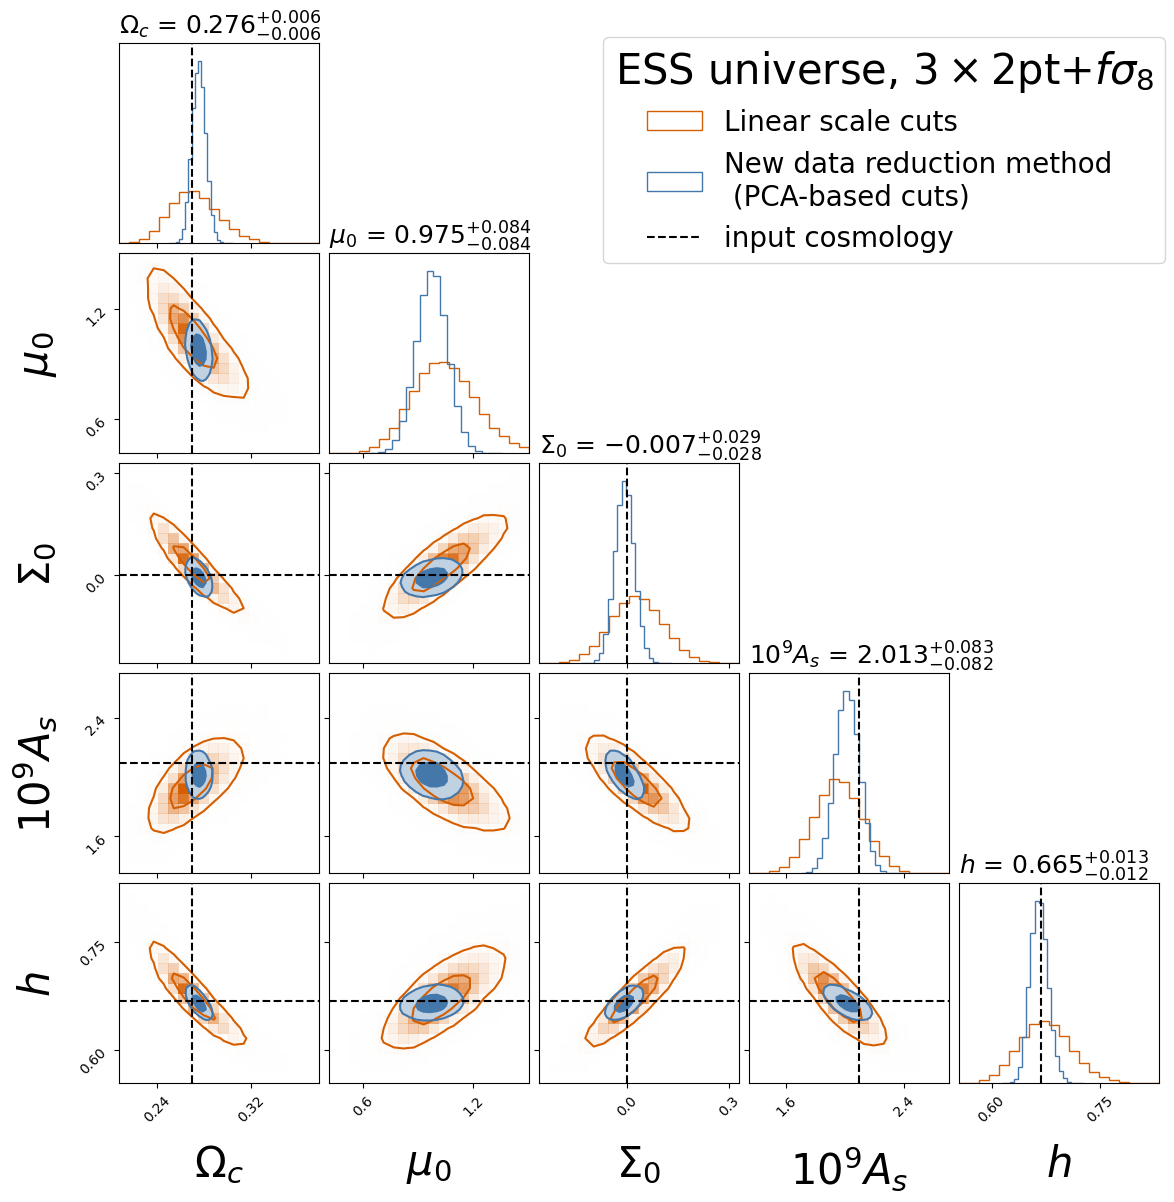

In [443]:
#### STANDARD CUTS #####

print(value1[:ndim])
print(list(max_likelihood_params)[:ndim])
ndim = 5#len(labels)
burned_chain = raw_chain_standardcuts

colors = ["#4477AA",mcolors.to_hex(col[3])]  # Contour colors
truth_color = "k"  # Truth values

CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = False,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=False,
    max_n_ticks=2,
    title_fmt=".3f"
)

flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

print(flat_samples.shape)
len_chain_standardcuts = flat_samples.shape[0]

figure = corner.corner(
    flat_samples, **CORNER_KWARGS, labels=labels, color = colors[1],hist_kwargs=dict(density=True)
);
"""
"""
# COMPUTE STD DIFFERENCE FROM TRUTH
posterior_means = np.mean(flat_samples, axis=0)
posterior_stds = np.std(flat_samples, axis=0)

# Compute Z-score (number of sigmas away from truth values)
sigmas_away = np.abs((value1[:ndim] - posterior_means) / posterior_stds)

# Print the results
print(f"mu_0: Truth = {value1[1]:.3f}, Mean = {posterior_means[1]:.3f}, "
      f"Std = {posterior_stds[1]:.3f}, Sigma Away = {sigmas_away[1]:.2f}σ")


### PCA CUTS####

burned_chain = raw_chain
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=18, loc="left"),
    show_titles=True,
    smooth = False,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=2,
    title_fmt=".3f"
)

print(flat_samples.shape)

figure = corner.corner(
    flat_samples,fig=figure, **CORNER_KWARGS, labels=labels, color=colors[0],hist_kwargs=dict(density=True)
);

# COMPUTE STD DIFFERENCE FROM TRUTH
posterior_means = np.mean(flat_samples, axis=0)
posterior_stds = np.std(flat_samples, axis=0)

# Compute Z-score (number of sigmas away from truth values)
sigmas_away = np.abs((value1[:ndim] - posterior_means) / posterior_stds)

# Print the results
for i in range(ndim):
    print(f"param: Truth = {value1[i]:.3f}, Mean = {posterior_means[i]:.3f}, "
          f"Std = {posterior_stds[i]:.3f}, Sigma Away = {sigmas_away[i]:.2f}σ")


## Add PCA for parameterized version
"""
CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = 0.5,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=2,
    title_fmt=".4f"
)

burnin = 0
burned_chain = raw_chain_PCAGRonlycuts[burnin:, :, :]
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

corner.corner(
    flat_samples, fig=figure, **CORNER_KWARGS, labels=labels, color=mcolors.to_hex(col[2]),hist_kwargs=dict(density=True)
);

# COMPUTE STD DIFFERENCE FROM TRUTH
posterior_means = np.mean(flat_samples, axis=0)
posterior_stds = np.std(flat_samples, axis=0)

# Compute Z-score (number of sigmas away from truth values)
sigmas_away = np.abs((value1[:ndim] - posterior_means) / posterior_stds)

# Print the results
for i in range(ndim):
    print(f"param: Truth = {value1[i]:.3f}, Mean = {posterior_means[i]:.3f}, "
          f"Std = {posterior_stds[i]:.3f}, Sigma Away = {sigmas_away[i]:.2f}σ")


for ax in figure.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=15)  # Change label size
"""
######################
# Extract the axes
axes = np.array(figure.axes).reshape((ndim, ndim))

# Loop over the diagonal
for i in range(ndim):
    if value1[i] != None:
        ax = axes[i, i]
        ax.axvline(value1[i], color=truth_color, linestyle="--")

# Loop over histograms
for yi in range(ndim):
    for xi in range(yi):
        if value1[xi] == None:
            ax = axes[yi, xi]
            ax.axhline(value1[yi], color=truth_color, linestyle="--")
        elif value1[yi] == None:
            ax = axes[yi, xi]
            ax.axvline(value1[xi], color=truth_color, linestyle="--")
        else:
            ax = axes[yi, xi]
            ax.axvline(value1[xi], color=truth_color, linestyle="--")
            ax.axhline(value1[yi], color=truth_color, linestyle="--")
####################



plt.legend(["Linear scale cuts","New data reduction method \n (PCA-based cuts)","input cosmology", r"PCA cuts, $\Lambda$-parametrization"], bbox_to_anchor=(1.1, 5.3), fontsize=20,title=r"ESS universe, $3\times2$pt$+f\sigma_8$",title_fontsize=30)

#plt.legend([r"PCA cuts, ESS-specific parametrization",r"PCA cuts, $\Lambda$-parametrization","input cosmology"], bbox_to_anchor=(1.2, 5.3), fontsize=20,title=r"ESS universe, $3\times2$pt$+f\sigma_8$",title_fontsize=30)

#plt.savefig("/home/c2042999/PCA_project/Figures/Final_figures/3x2pt_fs8_ESS_mild_marg.pdf", bbox_inches='tight')


[0.269619, None, 0.0, 2.0919999999999996, 0.6688]
[0.2767341794578001, 0.9789619330862238, -0.013269810157927987, 2.007329700851711, 0.6654275733706593]
(67640, 12)
(1152000, 12)


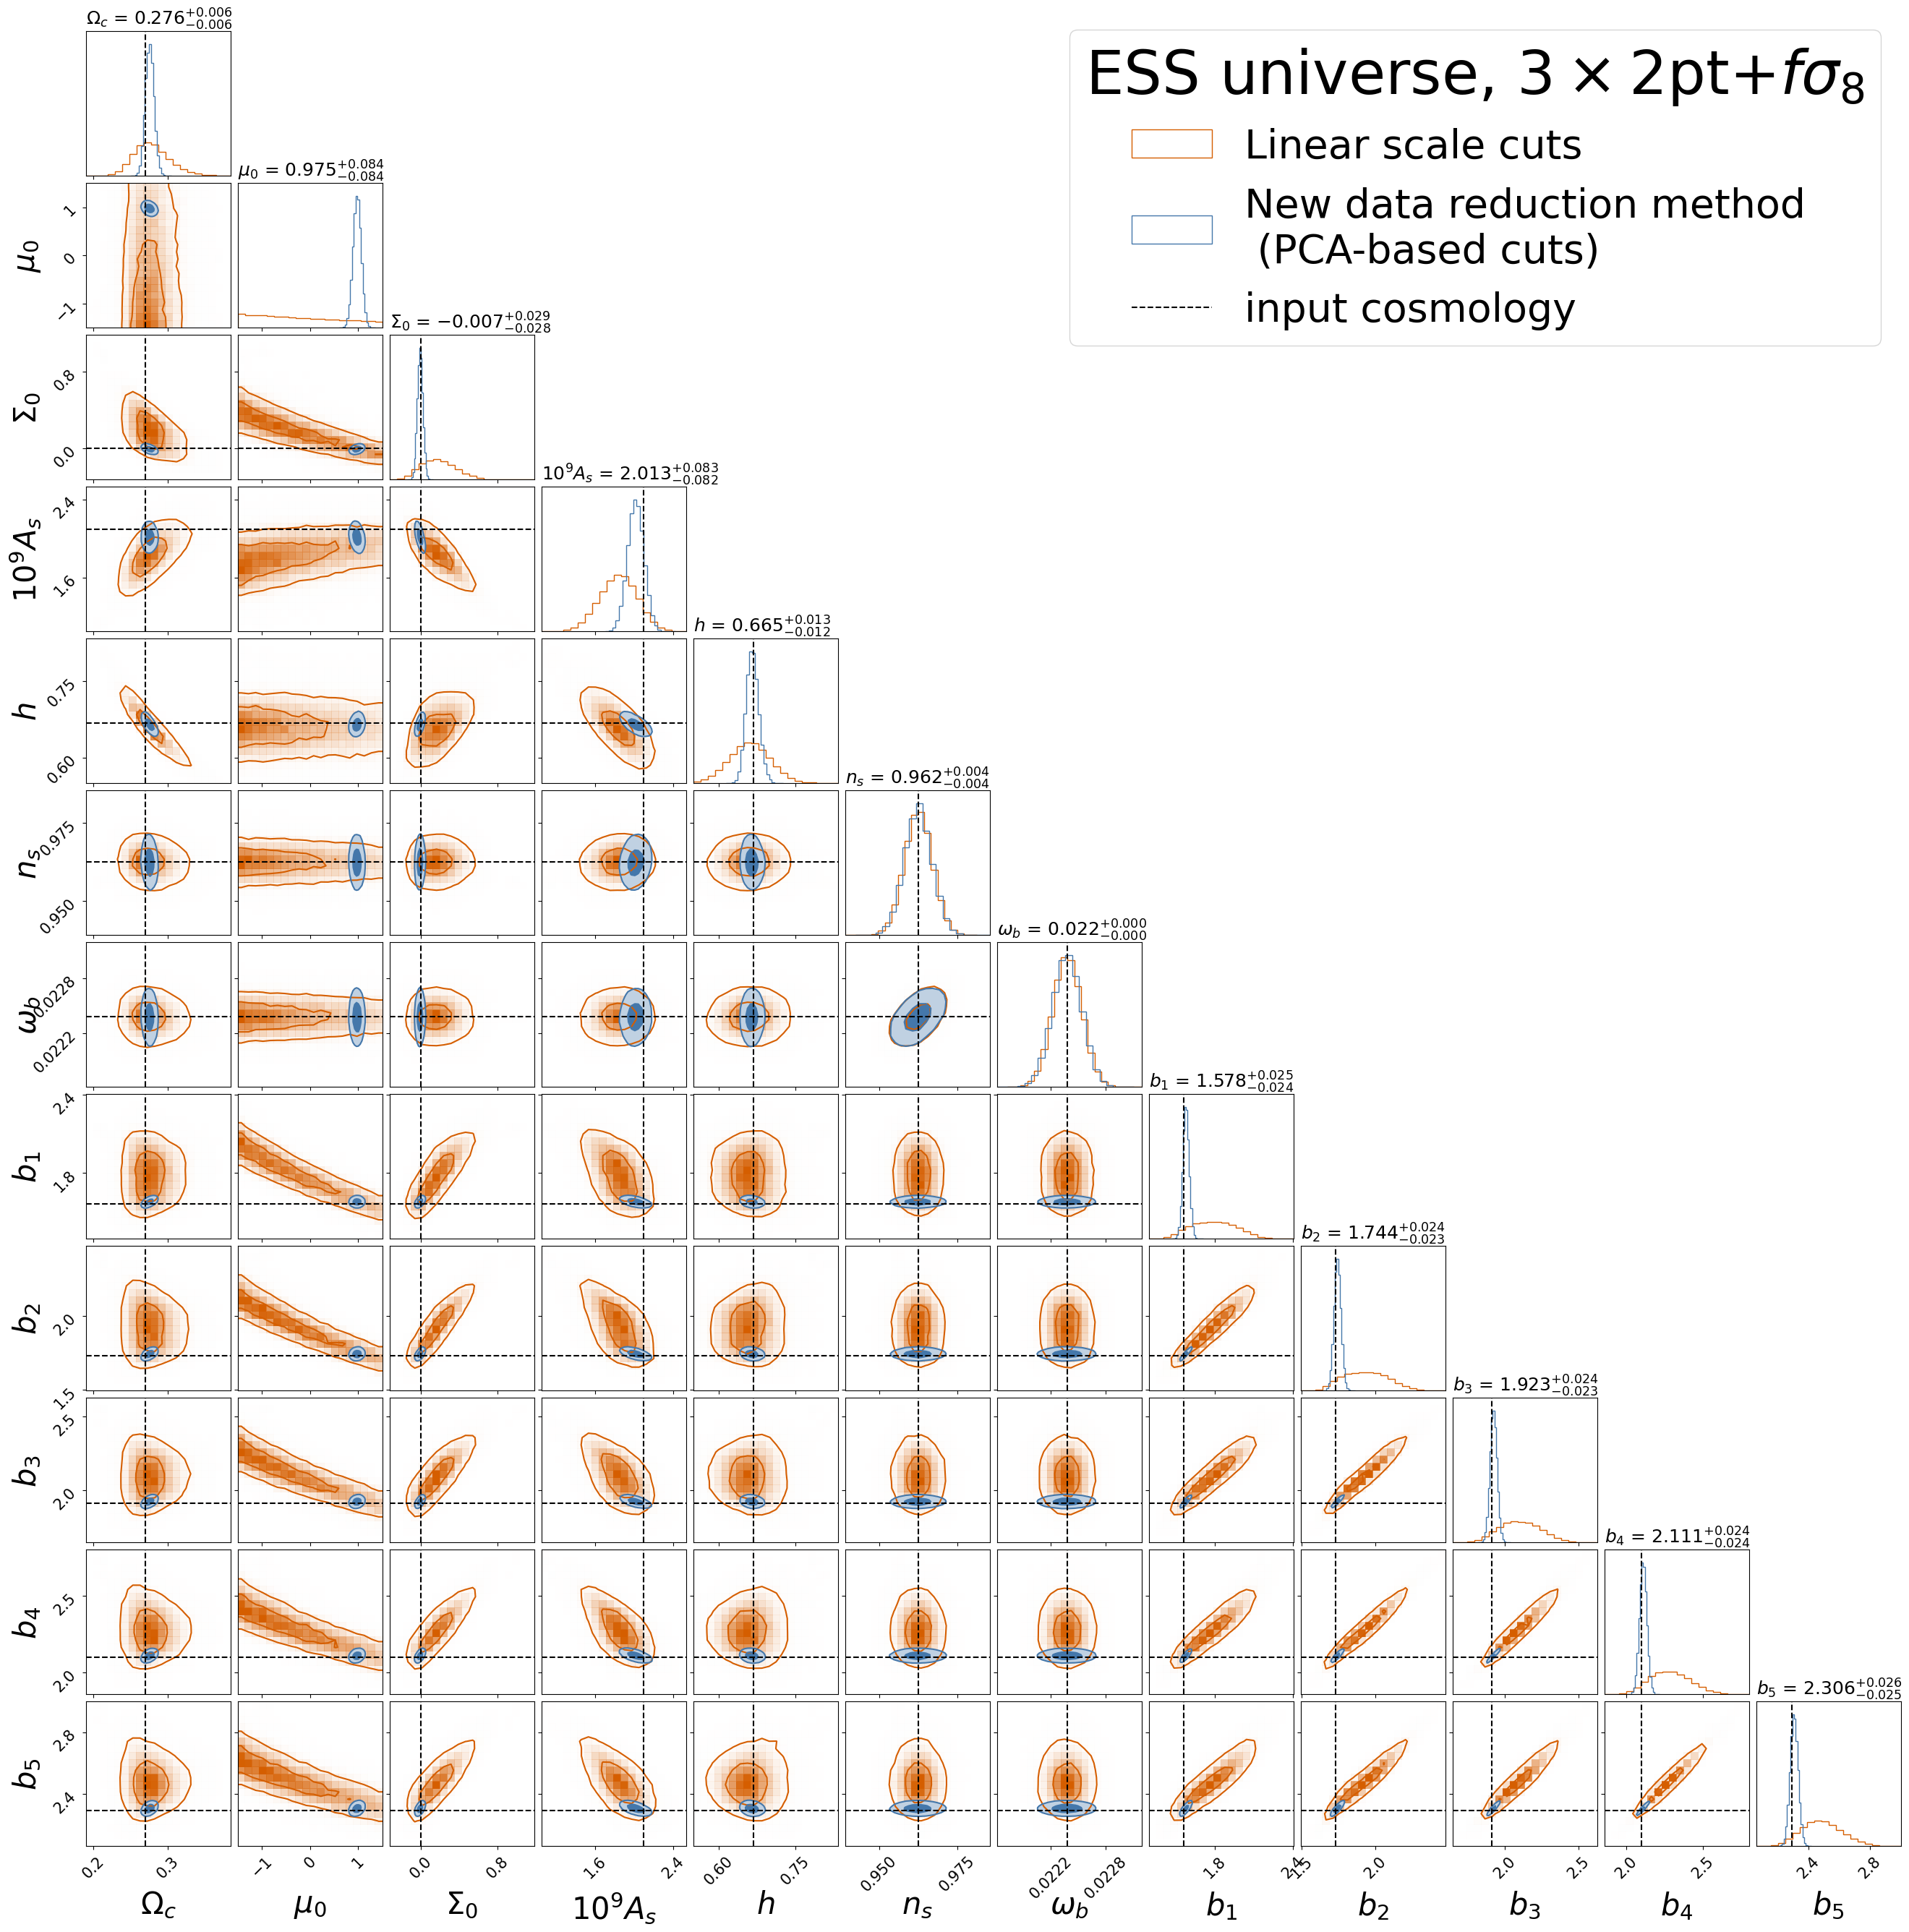

In [344]:
#### STANDARD CUTS #####
print(value1[:ndim])
print(list(max_likelihood_params)[:ndim])
ndim = len(labels)
burned_chain = raw_chain_standardcuts

colors = ["#4477AA",mcolors.to_hex(col[3])]  # Contour colors
truth_color = "k"  # Truth values

CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = False,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=False,
    max_n_ticks=2,
    title_fmt=".3f"
)

flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

print(flat_samples.shape)
len_chain_standardcuts = flat_samples.shape[0]

figure = corner.corner(
    flat_samples, **CORNER_KWARGS, labels=labels, color = colors[1],hist_kwargs=dict(density=True)
);

### PCA CUTS####

burned_chain = raw_chain
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=18, loc="left"),
    show_titles=True,
    smooth = False,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=2,
    title_fmt=".3f"
)

print(flat_samples.shape)

corner.corner(
    flat_samples, fig=figure, **CORNER_KWARGS, labels=labels, color=colors[0],hist_kwargs=dict(density=True)
);


######################
# Extract the axes
axes = np.array(figure.axes).reshape((ndim, ndim))

# Loop over the diagonal
for i in range(ndim):
    if value1[i] != None:
        ax = axes[i, i]
        ax.axvline(value1[i], color=truth_color, linestyle="--")

# Loop over histograms
for yi in range(ndim):
    for xi in range(yi):
        if value1[xi] == None:
            ax = axes[yi, xi]
            ax.axhline(value1[yi], color=truth_color, linestyle="--")
        elif value1[yi] == None:
            ax = axes[yi, xi]
            ax.axvline(value1[xi], color=truth_color, linestyle="--")
        else:
            ax = axes[yi, xi]
            ax.axvline(value1[xi], color=truth_color, linestyle="--")
            ax.axhline(value1[yi], color=truth_color, linestyle="--")
########################
"""
## Add PCA for parameterized version
CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = False,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=2,
    title_fmt=".4f",
    truths=value1[:ndim],
    truth_color=mcolors.to_hex(col[4])
)

burnin = 0
burned_chain = raw_chain_PCAGRonlycuts[burnin:, :, :]
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]


corner.corner(
    flat_samples, fig=figure, **CORNER_KWARGS, labels=labels, color=mcolors.to_hex(col[2]),hist_kwargs=dict(density=True)
);
"""
for ax in figure.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=15)  # Change label size
 
plt.legend(["Linear scale cuts","New data reduction method \n (PCA-based cuts)","input cosmology", r"PCA cuts, $\Lambda$-parametrization"],\
           bbox_to_anchor=(1.0, 12.7), fontsize=40,title=r"ESS universe, $3\times2$pt$+f\sigma_8$",title_fontsize=60)
#plt.legend(["Linear scale cuts","New data reduction method \n (PCA-based cuts)","input cosmology", r"PCA cuts, $\Lambda$-parametrization"], bbox_to_anchor=(1.1, 5.3), fontsize=20,title=r"ESS universe",title_fontsize=30)

#plt.savefig("/home/c2042999/PCA_project/Figures/Final_figures/3x2pt_fs8_ESS_mild.pdf", bbox_inches='tight')


(1152000, 5)
mu_0: Truth = 0.000, Mean = 0.975, Std = 0.085, Sigma Away = 11.52σ
param: Truth = 0.270, Mean = 0.280, Std = 0.005, Sigma Away = 1.83σ
param: Truth = 0.000, Mean = 0.970, Std = 0.083, Sigma Away = 11.69σ
param: Truth = 0.000, Mean = -0.012, Std = 0.024, Sigma Away = 0.49σ
param: Truth = 2.092, Mean = 2.059, Std = 0.065, Sigma Away = 0.51σ
param: Truth = 0.669, Mean = 0.654, Std = 0.008, Sigma Away = 1.85σ


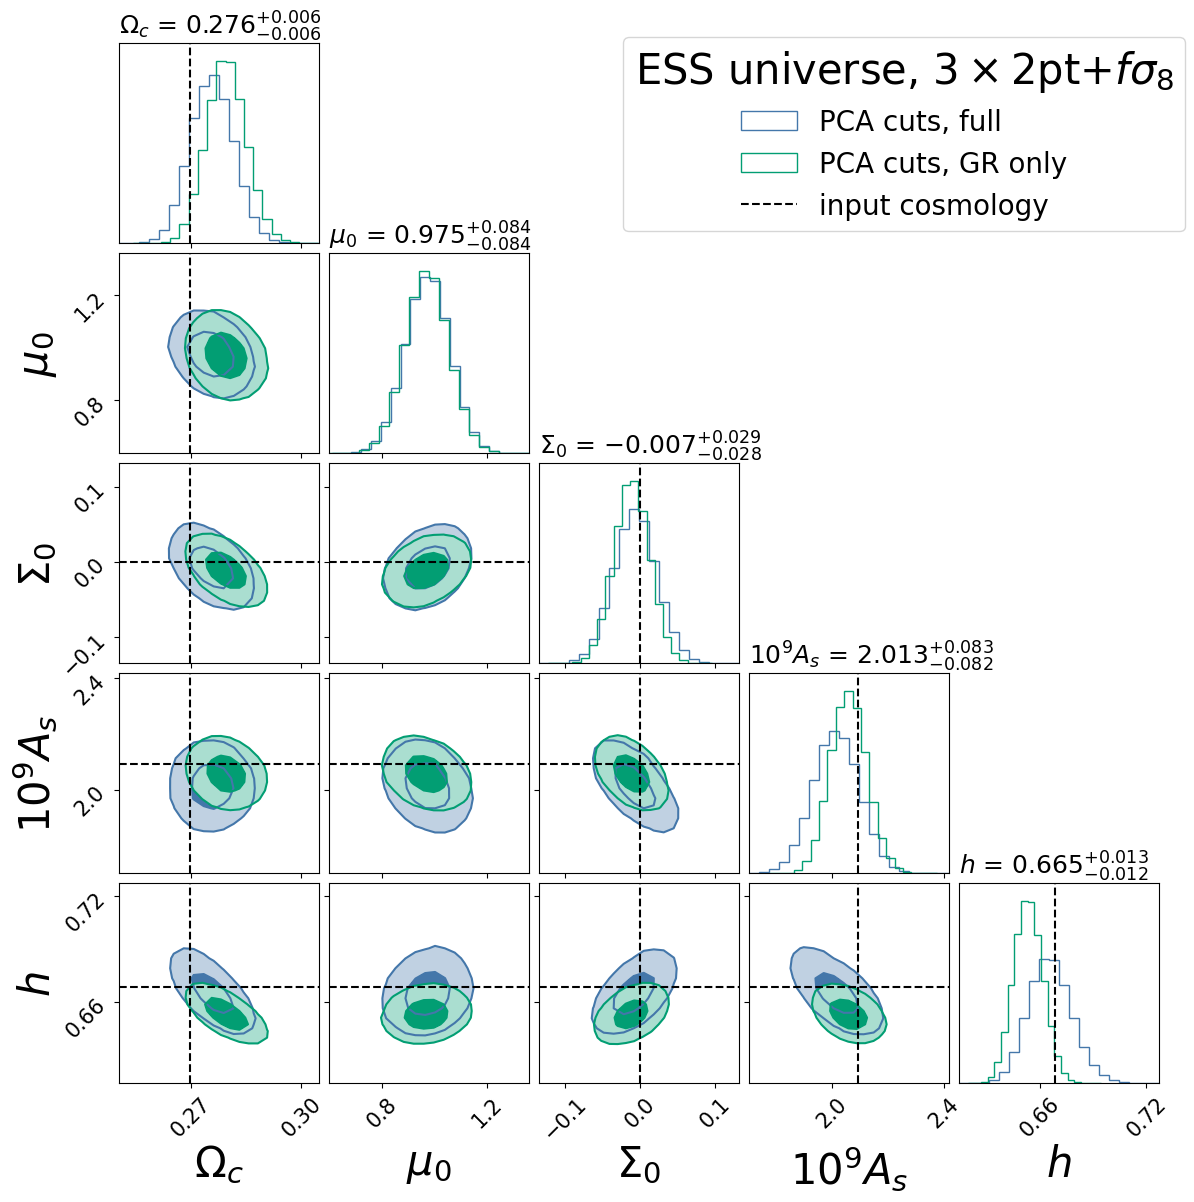

In [17]:
#### STANDARD CUTS #####
colors = ["#4477AA",mcolors.to_hex(col[3])]  # Contour colors
truth_color = "k"  # Truth values
"""
print(value1[:ndim])
print(list(max_likelihood_params)[:ndim])
burned_chain = raw_chain_standardcuts

colors = ["#4477AA",mcolors.to_hex(col[3])]  # Contour colors
truth_color = "k"  # Truth values

CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = False,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=False,
    max_n_ticks=2,
    title_fmt=".3f"
)

flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

print(flat_samples.shape)
len_chain_standardcuts = flat_samples.shape[0]

figure = corner.corner(
    flat_samples, **CORNER_KWARGS, labels=labels, color = colors[1],hist_kwargs=dict(density=True)
);
"""
"""
# COMPUTE STD DIFFERENCE FROM TRUTH
posterior_means = np.mean(flat_samples, axis=0)
posterior_stds = np.std(flat_samples, axis=0)

# Compute Z-score (number of sigmas away from truth values)
sigmas_away = np.abs((value1[:ndim] - posterior_means) / posterior_stds)

# Print the results
print(f"mu_0: Truth = {value1[1]:.3f}, Mean = {posterior_means[1]:.3f}, "
      f"Std = {posterior_stds[1]:.3f}, Sigma Away = {sigmas_away[1]:.2f}σ")
"""
ndim = 5#len(labels)

### PCA CUTS####

burned_chain = raw_chain
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=18, loc="left"),
    show_titles=True,
    smooth = False,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=2,
    title_fmt=".3f"
)

print(flat_samples.shape)

figure = corner.corner(
    flat_samples, **CORNER_KWARGS, labels=labels, color=colors[0],hist_kwargs=dict(density=True)
);

# COMPUTE STD DIFFERENCE FROM TRUTH
posterior_means = np.mean(flat_samples, axis=0)
posterior_stds = np.std(flat_samples, axis=0)

# Compute Z-score (number of sigmas away from truth values)
sigmas_away = np.abs((value1[:ndim] - posterior_means) / posterior_stds)

# Print the results
print(f"mu_0: Truth = {value1[1]:.3f}, Mean = {posterior_means[1]:.3f}, "
      f"Std = {posterior_stds[1]:.3f}, Sigma Away = {sigmas_away[1]:.2f}σ")


## Add PCA for parameterized version

CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = 0.5,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=2,
    title_fmt=".4f"
)

burnin = 0
burned_chain = raw_chain_PCAGRonlycuts[burnin:, :, :]
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

corner.corner(
    flat_samples, fig=figure, **CORNER_KWARGS, labels=labels, color=mcolors.to_hex(col[2]),hist_kwargs=dict(density=True)
);

# COMPUTE STD DIFFERENCE FROM TRUTH
posterior_means = np.mean(flat_samples, axis=0)
posterior_stds = np.std(flat_samples, axis=0)

# Compute Z-score (number of sigmas away from truth values)
sigmas_away = np.abs((value1[:ndim] - posterior_means) / posterior_stds)

# Print the results
for i in range(ndim):
    print(f"param: Truth = {value1[i]:.3f}, Mean = {posterior_means[i]:.3f}, "
          f"Std = {posterior_stds[i]:.3f}, Sigma Away = {sigmas_away[i]:.2f}σ")


for ax in figure.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=15)  # Change label size

######################
# Extract the axes
axes = np.array(figure.axes).reshape((ndim, ndim))

# Loop over the diagonal
for i in range(ndim):
    if value1[i] != None:
        ax = axes[i, i]
        ax.axvline(value1[i], color=truth_color, linestyle="--")

# Loop over histograms
for yi in range(ndim):
    for xi in range(yi):
        if value1[xi] == None:
            ax = axes[yi, xi]
            ax.axhline(value1[yi], color=truth_color, linestyle="--")
        elif value1[yi] == None:
            ax = axes[yi, xi]
            ax.axvline(value1[xi], color=truth_color, linestyle="--")
        else:
            ax = axes[yi, xi]
            ax.axvline(value1[xi], color=truth_color, linestyle="--")
            ax.axhline(value1[yi], color=truth_color, linestyle="--")
######################



#plt.legend(["Linear scale cuts","New data reduction method \n (PCA-based cuts)","input cosmology", r"PCA cuts, $\Lambda$-parametrization"], bbox_to_anchor=(1.1, 5.3), fontsize=20,title=r"ESS universe, $3\times2$pt$+f\sigma_8$",title_fontsize=30)

#plt.legend([r"PCA cuts, ESS-specific parametrization",r"PCA cuts, $\Lambda$-parametrization","input cosmology"], bbox_to_anchor=(1.2, 5.3), fontsize=20,title=r"ESS universe, $3\times2$pt$+f\sigma_8$",title_fontsize=30)
plt.legend([r"PCA cuts, full",r"PCA cuts, GR only","input cosmology"], bbox_to_anchor=(1.2, 5.3), fontsize=20,title=r"ESS universe, $3\times2$pt$+f\sigma_8$",title_fontsize=30)

#plt.savefig("/home/c2042999/PCA_project/Figures/Final_figures/3x2pt_fs8_ESS_mild_marg_GRonly.pdf", bbox_inches='tight')


(55600, 5)
mu_0: Truth = 0.000, Mean = 0.974, Std = 0.085, Sigma Away = 11.44σ
param: Truth = 0.270, Mean = 0.276, Std = 0.005, Sigma Away = 1.25σ
param: Truth = 0.000, Mean = 0.973, Std = 0.089, Sigma Away = 10.90σ
param: Truth = 0.000, Mean = 0.026, Std = 0.023, Sigma Away = 1.12σ
param: Truth = 2.092, Mean = 1.788, Std = 0.053, Sigma Away = 5.78σ
param: Truth = 0.669, Mean = 0.682, Std = 0.009, Sigma Away = 1.46σ


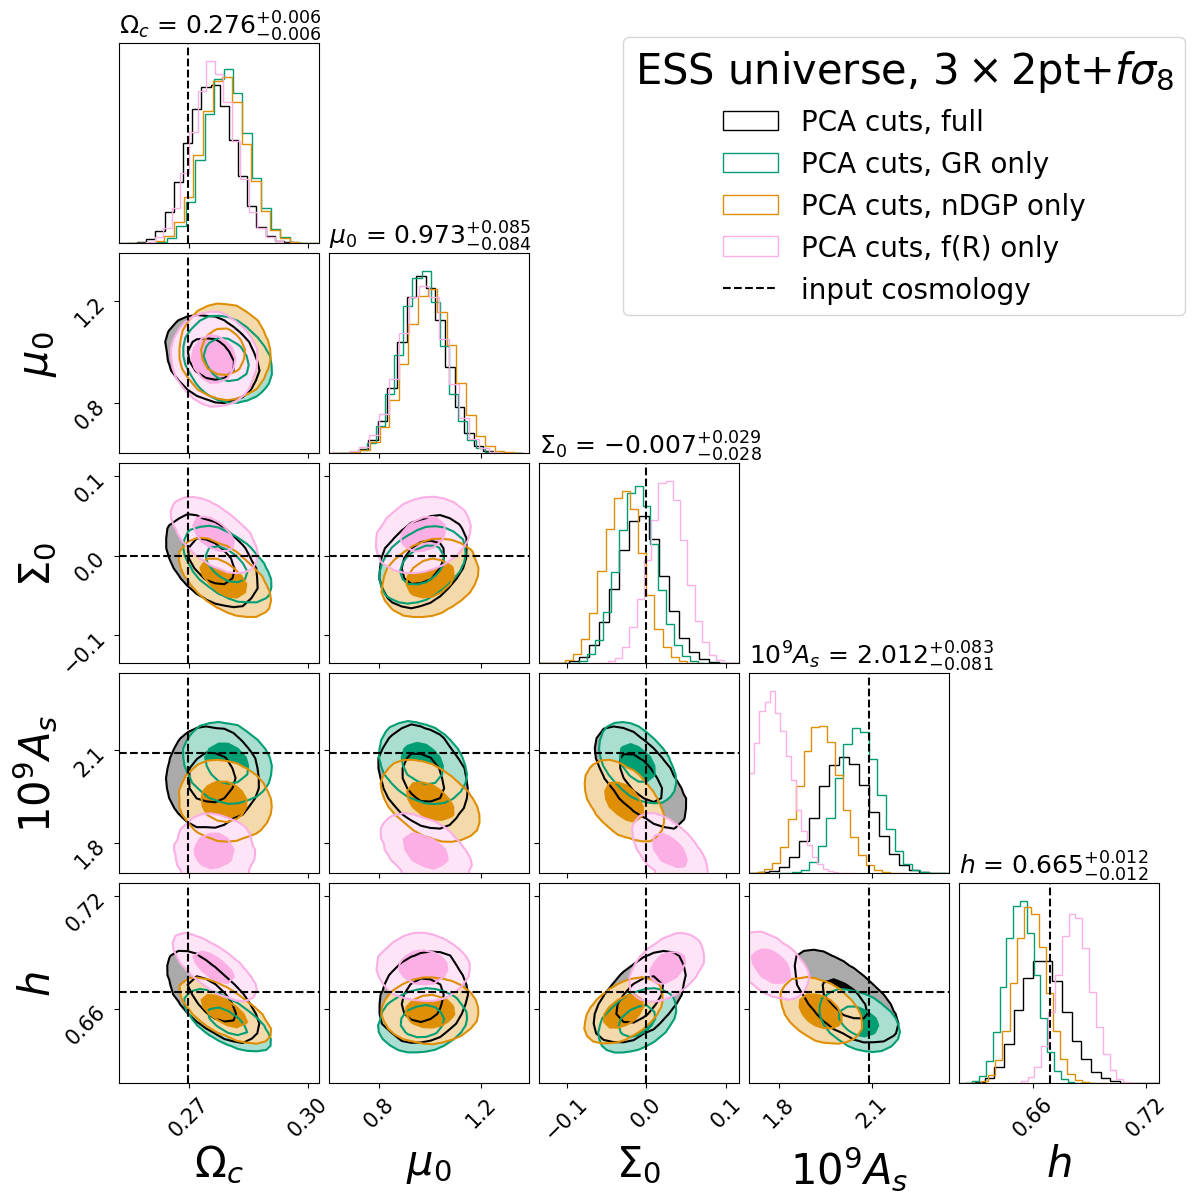

In [71]:
#### STANDARD CUTS #####
colors = ["#4477AA",mcolors.to_hex(col[3])]  # Contour colors
truth_color = "k"  # Truth values

ndim = 5#len(labels)

### PCA CUTS####

burned_chain = raw_chain
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=18, loc="left"),
    show_titles=True,
    smooth = False,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=2,
    title_fmt=".3f"
)

print(flat_samples.shape)

figure = corner.corner(
    flat_samples, **CORNER_KWARGS, labels=labels, color="k",hist_kwargs=dict(density=True)
);

# COMPUTE STD DIFFERENCE FROM TRUTH
posterior_means = np.mean(flat_samples, axis=0)
posterior_stds = np.std(flat_samples, axis=0)

# Compute Z-score (number of sigmas away from truth values)
sigmas_away = np.abs((value1[:ndim] - posterior_means) / posterior_stds)

# Print the results
print(f"mu_0: Truth = {value1[1]:.3f}, Mean = {posterior_means[1]:.3f}, "
      f"Std = {posterior_stds[1]:.3f}, Sigma Away = {sigmas_away[1]:.2f}σ")


## Add PCA for GRonly version

CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = 0.5,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=2,
    title_fmt=".4f"
)

burnin = 0
burned_chain = raw_chain_PCAGRonlycuts[burnin:, :, :]
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

corner.corner(
    flat_samples, fig=figure, **CORNER_KWARGS, labels=labels, color=mcolors.to_hex(col[2]),hist_kwargs=dict(density=True)
);

## Add PCA for nDGPonly version

CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = 0.5,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=2,
    title_fmt=".4f"
)

burnin = 0
burned_chain = raw_chain_PCAnDGPonlycuts[burnin:, :, :]
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

corner.corner(
    flat_samples, fig=figure, **CORNER_KWARGS, labels=labels, color=mcolors.to_hex(col[1]),hist_kwargs=dict(density=True)
);

## Add PCA for fRonly version

CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = 0.5,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=2,
    title_fmt=".4f"
)

burnin = 0
burned_chain = raw_chain_PCAfRonlycuts[burnin:, :, :]
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

corner.corner(
    flat_samples, fig=figure, **CORNER_KWARGS, labels=labels, color=mcolors.to_hex(col[6]),hist_kwargs=dict(density=True)
);

# COMPUTE STD DIFFERENCE FROM TRUTH
posterior_means = np.mean(flat_samples, axis=0)
posterior_stds = np.std(flat_samples, axis=0)

# Compute Z-score (number of sigmas away from truth values)
sigmas_away = np.abs((value1[:ndim] - posterior_means) / posterior_stds)

# Print the results
for i in range(ndim):
    print(f"param: Truth = {value1[i]:.3f}, Mean = {posterior_means[i]:.3f}, "
          f"Std = {posterior_stds[i]:.3f}, Sigma Away = {sigmas_away[i]:.2f}σ")


for ax in figure.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=15)  # Change label size

######################
# Extract the axes
axes = np.array(figure.axes).reshape((ndim, ndim))

# Loop over the diagonal
for i in range(ndim):
    if value1[i] != None:
        ax = axes[i, i]
        ax.axvline(value1[i], color=truth_color, linestyle="--")

# Loop over histograms
for yi in range(ndim):
    for xi in range(yi):
        if value1[xi] == None:
            ax = axes[yi, xi]
            ax.axhline(value1[yi], color=truth_color, linestyle="--")
        elif value1[yi] == None:
            ax = axes[yi, xi]
            ax.axvline(value1[xi], color=truth_color, linestyle="--")
        else:
            ax = axes[yi, xi]
            ax.axvline(value1[xi], color=truth_color, linestyle="--")
            ax.axhline(value1[yi], color=truth_color, linestyle="--")
######################



#plt.legend(["Linear scale cuts","New data reduction method \n (PCA-based cuts)","input cosmology", r"PCA cuts, $\Lambda$-parametrization"], bbox_to_anchor=(1.1, 5.3), fontsize=20,title=r"ESS universe, $3\times2$pt$+f\sigma_8$",title_fontsize=30)

#plt.legend([r"PCA cuts, ESS-specific parametrization",r"PCA cuts, $\Lambda$-parametrization","input cosmology"], bbox_to_anchor=(1.2, 5.3), fontsize=20,title=r"ESS universe, $3\times2$pt$+f\sigma_8$",title_fontsize=30)
plt.legend([r"PCA cuts, full",r"PCA cuts, GR only",r"PCA cuts, nDGP only",r"PCA cuts, f(R) only","input cosmology"], bbox_to_anchor=(1.2, 5.3), fontsize=20,title=r"ESS universe, $3\times2$pt$+f\sigma_8$",title_fontsize=30)

#plt.savefig("/home/c2042999/PCA_project/Figures/Final_figures/3x2pt_fs8_ESS_mild_marg_GRonly.pdf", bbox_inches='tight')


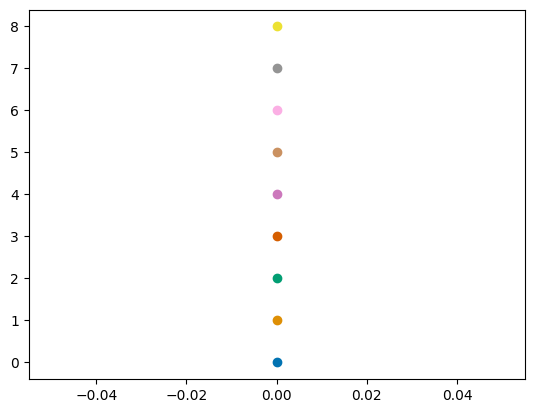

In [379]:
for i in range(9):
    plt.scatter(0,i,color=mcolors.to_hex(col[i]))


## WAIC criterion

In [43]:
import h5py

In [46]:
# Load the MCMC samples and log-likelihoods
def load_mcmc_data(filename):
    with h5py.File(filename, 'r') as f:
        samples = f['mcmc']['chain'][...]      # shape: (n_walkers, n_steps, n_params)
        log_likelihood = f['mcmc']['log_prob'][...]  # shape: (n_walkers, n_steps)
    return samples, log_likelihood

# Files for both models
file_model_1 = '/scratch/c2042999/chains/mcmc_ESS_muSigma_PCACuts_noparam.h5'
file_model_2 = '/scratch/c2042999/chains/mcmc_ESS_muSigma_StandardCuts_noparam.h5'

samples_1, log_likelihood_1 = load_mcmc_data(file_model_1)
samples_2, log_likelihood_2 = load_mcmc_data(file_model_2)

In [47]:
def compute_waic(log_likelihood):
    # Reshape to (n_samples, n_data) if needed
    log_likelihood = log_likelihood.reshape(-1, log_likelihood.shape[-1])

    # Log Pointwise Predictive Density (lppd)
    lppd = np.sum(np.log(np.mean(np.exp(log_likelihood), axis=0)))

    # Effective number of parameters (p_WAIC)
    p_waic = np.sum(np.var(log_likelihood, axis=0))

    # WAIC Calculation
    waic = -2 * (lppd - p_waic)
    return waic

# WAIC for both models
waic_model_1 = compute_waic(log_likelihood_1)
waic_model_2 = compute_waic(log_likelihood_2)

# Display the results
print(f"WAIC for Model 1 (PCA Cuts): {waic_model_1}")
print(f"WAIC for Model 2 (Standard Cuts): {waic_model_2}")

WAIC for Model 1 (PCA Cuts): 14892.2541258095
WAIC for Model 2 (Standard Cuts): 4487.198990053972


In [48]:
def waic_se(log_likelihood):
    log_likelihood = log_likelihood.reshape(-1, log_likelihood.shape[-1])
    return np.sqrt(len(log_likelihood[0]) * np.var(np.var(log_likelihood, axis=0)))

se_model_1 = waic_se(log_likelihood_1)
se_model_2 = waic_se(log_likelihood_2)

delta_waic = waic_model_1 - waic_model_2
se_delta = np.sqrt(se_model_1**2 + se_model_2**2)

print(f"ΔWAIC = {delta_waic} ± {se_delta}")

ΔWAIC = 10405.055135755529 ± 406.0781495587649
